In [25]:
# can you load the pickle file at the following path: '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/subject_data_1_cleaned_precise_age.pkl' ?
import pickle
import random

with open('/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/subject_data_1_cleaned_precise_age.pkl', 'rb') as f:
    data = pickle.load(f)

fc_matrices = [data[subject_id]['FC'] for subject_id in data]
print(f"Number of subjects: {len(fc_matrices)}")

subject_id = random.choice(list(data.keys()))
print(f"Subject ID: {subject_id}")
print(data[subject_id]['FC'])
print(data[subject_id]['gender'])
print(data[subject_id]['age'])
print(data[subject_id]['FC'].shape)

Number of subjects: 748
Subject ID: 522434
[[1.         0.59549115 0.84781854 ... 0.48012236 0.51609122 0.27390975]
 [0.59549115 1.         0.4920629  ... 0.52725738 0.53623902 0.32363645]
 [0.84781854 0.4920629  1.         ... 0.26438861 0.26867701 0.05849331]
 ...
 [0.48012236 0.52725738 0.26438861 ... 1.         0.89124184 0.70838289]
 [0.51609122 0.53623902 0.26867701 ... 0.89124184 1.         0.68902591]
 [0.27390975 0.32363645 0.05849331 ... 0.70838289 0.68902591 1.        ]]
F
27
(379, 379)


/Users/stefanovannoni/.pyenv/versions/imperial/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Label: 6
Image shape: torch.Size([3, 32, 32])


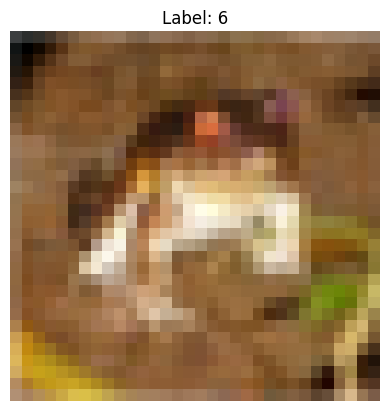

In [2]:
# can you import cifiar10 and load one image using pytorch?
import torch
import torchvision
import torchvision.transforms as transforms

# Define a transform to convert the images to tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load the CIFAR-10 dataset
cifar10_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)   

# Get one image and its label
image, label = cifar10_dataset[0]
print(f"Label: {label}")
print(f"Image shape: {image.shape}")

# can you display the image using matplotlib?
import matplotlib.pyplot as plt
import numpy as np
# Convert the image tensor to a numpy array and transpose it to (H, W, C)
image_np = image.numpy().transpose((1, 2, 0))
# Display the image
plt.imshow(image_np)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

Number of context panels : 8
Number of answer choices : 8
Correct answer index     : 3
Panel size               : (160, 160)  (W x H)


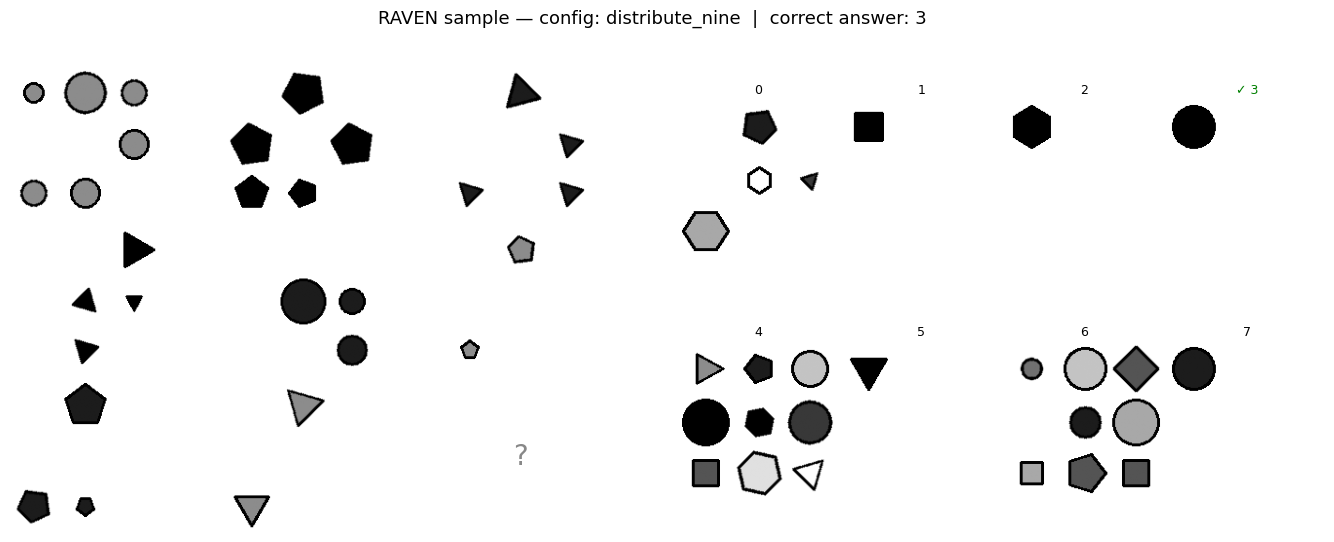

In [3]:

# Load a sample from the RAVEN dataset (HuggingFace)
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ds = load_dataset("HuggingFaceM4/RAVEN", "distribute_nine", split="train")

# Pick the first sample
sample = ds[45]
panels  = sample["panels"]   # 8 context images (the visible 3x3 matrix minus bottom-right)
choices = sample["choices"]  # 8 answer candidates
target  = sample["target"]   # correct answer index (0-7)

print(f"Number of context panels : {len(panels)}")
print(f"Number of answer choices : {len(choices)}")
print(f"Correct answer index     : {target}")
print(f"Panel size               : {panels[0].size}  (W x H)")

# --- plot ---
fig = plt.figure(figsize=(14, 6))
fig.suptitle(f"RAVEN sample — config: distribute_nine  |  correct answer: {target}", fontsize=13)

# Left: 3x3 context grid (panel 8 is the missing piece, shown as a blank)
gs_ctx = gridspec.GridSpec(3, 3, left=0.02, right=0.48, hspace=0.05, wspace=0.05)
for i in range(9):
    ax = fig.add_subplot(gs_ctx[i // 3, i % 3])
    if i < 8:
        ax.imshow(panels[i], cmap="gray", vmin=0, vmax=255)
    else:
        ax.set_facecolor("#dddddd")
        ax.text(0.5, 0.5, "?", ha="center", va="center", fontsize=20, color="#888888",
                transform=ax.transAxes)
    ax.axis("off")

# Right: 8 answer candidates (2 rows x 4 cols), correct one highlighted in green
gs_ans = gridspec.GridSpec(2, 4, left=0.52, right=0.98, hspace=0.1, wspace=0.05)
for i in range(8):
    ax = fig.add_subplot(gs_ans[i // 4, i % 4])
    ax.imshow(choices[i], cmap="gray", vmin=0, vmax=255)
    color = "limegreen" if i == target else "lightgray"
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(f"{'✓ ' if i == target else ''}{i}", fontsize=9,
                 color="green" if i == target else "black")
    ax.axis("off")

plt.show()


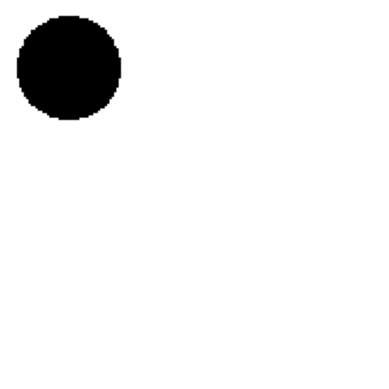

In [11]:
import matplotlib.pyplot as plt

plt.imshow(choices[3], cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [18]:
# can you open th following path '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/HCP_YA_subjects_2026_04_02_12_52_45.csv'
import pandas as pd
csv_path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/HCP_YA_subjects_2026_04_02_12_52_45.csv'
df = pd.read_csv(csv_path)

# print 20 random rows from the dataframe that have the pmat24_a_cr higher than 20, can you also count the number of male and female and give the mean age and standard deviation among only the one that you sampled?
filtered_df = df[df['PMAT24_A_CR'] > 20].sample(20, random_state=3)  # Sample 20 random rows with PMAT24_A_CR > 20
print(filtered_df)   
num_male = filtered_df[filtered_df['Gender'] == 'M'].shape[0]
num_female = filtered_df[filtered_df['Gender'] == 'F'].shape[0]
mean_age = filtered_df['Age_in_Yrs'].mean()
std_age = filtered_df['Age_in_Yrs'].std()
print(f"Number of male: {num_male}")
print(f"Number of female: {num_female}")
print(f"Mean age: {mean_age:.2f}")
print(f"Standard deviation of age: {std_age:.2f}")      

      Subject Gender  Age_in_Yrs  PMAT24_A_CR  PMAT24_A_RTCR
585    209531      F          36         21.0        19700.0
1194   984472      F          28         22.0        17689.0
455    185139      F          31         22.0        22032.5
423    177645      F          29         22.0        30865.0
1149   908860      M          28         22.0        24799.5
1001   713239      F          30         24.0        19322.0
1029   749058      M          24         24.0        16364.5
596    211518      F          25         21.0        28799.0
204    136530      M          34         21.0        18379.0
984    690152      M          30         23.0        32730.0
1073   815247      M          26         23.0        21510.0
944    638049      F          32         21.0        29903.0
943    635245      M          30         22.0        19447.0
916    601127      M          22         23.0        33629.0
310    155938      M          27         21.0        45590.0
826    513736      F    

In [26]:
# can you open th following path '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/HCP_YA_subjects_2026_04_02_12_52_45.csv'
import pandas as pd
csv_path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/HCP_YA_subjects_2026_04_02_12_52_45.csv'
df = pd.read_csv(csv_path)

# filter the dataframe with only those subjects that are present in data
subject_ids_in_data = [int(k) for k in data.keys()]
new_df = df[df['Subject'].isin(subject_ids_in_data)]

# print 20 random rows from the dataframe that have the pmat24_a_cr higher than 20, can you also count the number of male and female and give the mean age and standard deviation among only the one that you sampled?
filtered_df = new_df[new_df['PMAT24_A_CR'] <= 7].sample(20, random_state=5)  # Sample 20 random rows with PMAT24_A_CR > 20
print(filtered_df)   
num_male = filtered_df[filtered_df['Gender'] == 'M'].shape[0]
num_female = filtered_df[filtered_df['Gender'] == 'F'].shape[0]
mean_age = filtered_df['Age_in_Yrs'].mean()
std_age = filtered_df['Age_in_Yrs'].std()
print(f"Number of male: {num_male}")
print(f"Number of female: {num_female}")
print(f"Mean age: {mean_age:.2f}")
print(f"Standard deviation of age: {std_age:.2f}")      

      Subject Gender  Age_in_Yrs  PMAT24_A_CR  PMAT24_A_RTCR
964    668361      M          31          7.0         3090.0
892    579665      F          34          7.0        19141.0
436    180129      F          27          7.0         3610.0
603    212217      F          23          7.0         2680.0
906    588565      M          33          7.0         3810.0
580    208630      M          33          7.0         4489.0
883    571548      M          29          4.0         5935.0
1126   882161      F          29          7.0         5920.0
1095   837964      F          35          7.0         3460.0
658    274542      F          29          7.0         3380.0
461    186141      M          31          6.0         3854.0
407    175136      F          22          7.0         3070.0
618    217126      M          24          6.0         3089.5
806    473952      F          32          7.0         4320.0
375    169343      F          33          6.0         4453.5
1108   861456      F    

# 2 hidden layers MLP

## All subjects

### Brain-Brain

In [20]:
import numpy as np 
path_1 = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat higher than 20-20260525T104848Z-3-001/subjects with pmat higher than 20'
path_2 = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat lower than 7'

best_result_high = np.load(path_1 + '/val_acc_194443_random_kaiming.npy')

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies = []
best_accuracy_differences = []
for subject_id in subjects_list:
    try:
        result = np.load(path_1 + f'/val_acc_{subject_id}.npy')
        current_best = result.max()
        best_accuracies.append(current_best)
        best_accuracy_differences.append(best_result_high - current_best)
    except:
        result = np.load(path_2 + f'/val_acc_{subject_id}.npy')
        current_best = result.max()
        best_accuracies.append(current_best)
        best_accuracy_differences.append(best_result_high - current_best)

print(best_accuracies)
print(f"Mean best accuracy: {np.mean(best_accuracies):.4f}")
print(f"Standard deviation of best accuracies: {np.std(best_accuracies):.4f}")
print(f"Mean accuracy difference: {np.mean(best_accuracy_differences):.4f}")
print(f"Standard deviation of accuracy differences: {np.std(best_accuracy_differences):.4f}")

[np.float64(0.9338), np.float64(0.9644), np.float64(0.9497), np.float64(0.9478), np.float64(0.9634), np.float64(0.9673), np.float64(0.9392), np.float64(0.9705), np.float64(0.9726), np.float64(0.948), np.float64(0.9627), np.float64(0.9602), np.float64(0.9676), np.float64(0.9335), np.float64(0.9695), np.float64(0.9392), np.float64(0.953), np.float64(0.9704), np.float64(0.9634), np.float64(0.9535), np.float64(0.9523), np.float64(0.9702), np.float64(0.94), np.float64(0.9674), np.float64(0.9392), np.float64(0.9538), np.float64(0.9503), np.float64(0.9542), np.float64(0.9645), np.float64(0.9631)]
Mean best accuracy: 0.9562
Standard deviation of best accuracies: 0.0118
Mean accuracy difference: 0.0228
Standard deviation of accuracy differences: 0.0125


In [24]:
import numpy as np

path_1 = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat higher than 20-20260525T104848Z-3-001/subjects with pmat higher than 20'
path_2 = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat lower than 7'

best_result_high = np.load(path_1 +'/val_acc_194443_random_kaiming.npy').max()

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239,
749058, 690152, 815247,
    638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129,
181131, 183337, 186141, 189450, 194140, 208428, 208630,
    212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies_male = []
best_accuracies_female = []
best_accuracy_differences_male = []
best_accuracy_differences_female = []

for subject_id in subjects_list:
    try:
        result = np.load(path_1 + f'/val_acc_{subject_id}.npy')
    except:
        result = np.load(path_2 + f'/val_acc_{subject_id}.npy')

    current_best = result.max()
    sid = subject_id if subject_id in data else str(subject_id)
    gender = data[sid]['gender']

    if gender == 'M':
        best_accuracies_male.append(current_best)
        best_accuracy_differences_male.append(best_result_high -
current_best)
    else:
        best_accuracies_female.append(current_best)
        best_accuracy_differences_female.append(best_result_high -
current_best)

for label, accs, diffs in [('Male', best_accuracies_male,
best_accuracy_differences_male),
                            ('Female', best_accuracies_female,
best_accuracy_differences_female)]:
    print(f"\n=== {label} (n={len(accs)}) ===")
    print(f"  Accuracies : {accs}")
    print(f"  Mean accuracy      : {np.mean(accs):.4f}")
    print(f"  Std accuracy       : {np.std(accs):.4f}")
    print(f"  Mean diff (Kaiming - brain-init): {np.mean(diffs):.4f}")
    print(f"  Std  diff                       : {np.std(diffs):.4f}")


=== Male (n=14) ===
  Accuracies : [np.float64(0.9634), np.float64(0.9392), np.float64(0.9705), np.float64(0.9726), np.float64(0.9627), np.float64(0.9602), np.float64(0.9695), np.float64(0.9535), np.float64(0.9523), np.float64(0.9674), np.float64(0.9538), np.float64(0.9503), np.float64(0.9645), np.float64(0.9631)]
  Mean accuracy      : 0.9602
  Std accuracy       : 0.0090
  Mean diff (Kaiming - brain-init): 0.0234
  Std  diff                       : 0.0090

=== Female (n=16) ===
  Accuracies : [np.float64(0.9338), np.float64(0.9644), np.float64(0.9497), np.float64(0.9478), np.float64(0.9673), np.float64(0.948), np.float64(0.9676), np.float64(0.9335), np.float64(0.9392), np.float64(0.953), np.float64(0.9704), np.float64(0.9634), np.float64(0.9702), np.float64(0.94), np.float64(0.9392), np.float64(0.9542)]
  Mean accuracy      : 0.9526
  Std accuracy       : 0.0128
  Mean diff (Kaiming - brain-init): 0.0310
  Std  diff                       : 0.0128


### Brain-Random

In [31]:
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/metrics_brain_random'

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies = []

for subject_id in subjects_list:
    result = np.load(path + f'/val_acc_{subject_id}.npy')
    current_best = result.max()
    best_accuracies.append(current_best)

print(best_accuracies)
print(f"Mean best accuracy: {np.mean(best_accuracies):.4f}")
print(f"Standard deviation of best accuracies: {np.std(best_accuracies):.4f}")

[np.float64(0.978), np.float64(0.9794), np.float64(0.9748), np.float64(0.9765), np.float64(0.9793), np.float64(0.9782), np.float64(0.9758), np.float64(0.9787), np.float64(0.9795), np.float64(0.9786), np.float64(0.9789), np.float64(0.978), np.float64(0.9788), np.float64(0.9753), np.float64(0.9805), np.float64(0.9763), np.float64(0.9768), np.float64(0.9793), np.float64(0.9788), np.float64(0.9775), np.float64(0.9768), np.float64(0.9786), np.float64(0.9762), np.float64(0.979), np.float64(0.9765), np.float64(0.977), np.float64(0.9769), np.float64(0.9782), np.float64(0.9768), np.float64(0.978)]
Mean best accuracy: 0.9778
Standard deviation of best accuracies: 0.0014


In [32]:
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/metrics_brain_random'

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies_male = []
best_accuracies_female = []

for subject_id in subjects_list:
    result = np.load(path + f'/val_acc_{subject_id}.npy')
    current_best = result.max()
    sid = subject_id if subject_id in data else str(subject_id) 
    gender = data[sid]['gender']
    if gender == 'M':
        best_accuracies_male.append(current_best)
    else:
        best_accuracies_female.append(current_best)

for label, accs in [('Male', best_accuracies_male),
                            ('Female', best_accuracies_female)]:
    print(f"\n=== {label} (n={len(accs)}) ===")
    print(f"  Accuracies : {accs}")
    print(f"  Mean accuracy      : {np.mean(accs):.4f}")
    print(f"  Std accuracy       : {np.std(accs):.4f}")


=== Male (n=14) ===
  Accuracies : [np.float64(0.9793), np.float64(0.9758), np.float64(0.9787), np.float64(0.9795), np.float64(0.9789), np.float64(0.978), np.float64(0.9805), np.float64(0.9775), np.float64(0.9768), np.float64(0.979), np.float64(0.977), np.float64(0.9769), np.float64(0.9768), np.float64(0.978)]
  Mean accuracy      : 0.9781
  Std accuracy       : 0.0013

=== Female (n=16) ===
  Accuracies : [np.float64(0.978), np.float64(0.9794), np.float64(0.9748), np.float64(0.9765), np.float64(0.9782), np.float64(0.9786), np.float64(0.9788), np.float64(0.9753), np.float64(0.9763), np.float64(0.9768), np.float64(0.9793), np.float64(0.9788), np.float64(0.9786), np.float64(0.9762), np.float64(0.9765), np.float64(0.9782)]
  Mean accuracy      : 0.9775
  Std accuracy       : 0.0014


### Random-Brain

In [46]:
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/metrics'

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies = []

for subject_id in subjects_list:
    try:
        result = np.load(path + f'/val_acc_{subject_id}.npy')
        current_best = result.max()
        best_accuracies.append(current_best)
    except:
        pass

print(best_accuracies)
print(f"Mean best accuracy: {np.mean(best_accuracies):.4f}")
print(f"Standard deviation of best accuracies: {np.std(best_accuracies):.4f}")

[np.float64(0.9816), np.float64(0.9813), np.float64(0.9816), np.float64(0.9819), np.float64(0.9818), np.float64(0.981), np.float64(0.9812), np.float64(0.9818), np.float64(0.9821), np.float64(0.9806), np.float64(0.9823), np.float64(0.981), np.float64(0.9832), np.float64(0.9809)]
Mean best accuracy: 0.9816
Standard deviation of best accuracies: 0.0007


In [47]:
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/metrics'

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies_male = []
best_accuracies_female = []

for subject_id in subjects_list:
    try:
        result = np.load(path + f'/val_acc_{subject_id}.npy')
        current_best = result.max()
        sid = subject_id if subject_id in data else str(subject_id) 
        gender = data[sid]['gender']
        if gender == 'M':
            best_accuracies_male.append(current_best)
        else:
            best_accuracies_female.append(current_best)
    except:
        pass

for label, accs in [('Male', best_accuracies_male),
                            ('Female', best_accuracies_female)]:
    print(f"\n=== {label} (n={len(accs)}) ===")
    print(f"  Accuracies : {accs}")
    print(f"  Mean accuracy      : {np.mean(accs):.4f}")
    print(f"  Std accuracy       : {np.std(accs):.4f}")


=== Male (n=6) ===
  Accuracies : [np.float64(0.9818), np.float64(0.9812), np.float64(0.9818), np.float64(0.9821), np.float64(0.9823), np.float64(0.981)]
  Mean accuracy      : 0.9817
  Std accuracy       : 0.0005

=== Female (n=8) ===
  Accuracies : [np.float64(0.9816), np.float64(0.9813), np.float64(0.9816), np.float64(0.9819), np.float64(0.981), np.float64(0.9806), np.float64(0.9832), np.float64(0.9809)]
  Mean accuracy      : 0.9815
  Std accuracy       : 0.0008


## PMAT > 20

In [3]:
import numpy as np  
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat higher than 20-20260525T104848Z-3-001/subjects with pmat higher than 20'
best_result_high = np.load(path + '/val_acc_194443_random_kaiming.npy')
print(f"Best accuracy with random Kaiming init (high PMAT): {best_result_high.max():.4f}")
print('\n')

subject_id_list_high_pmat = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443]

best_accuracies_high_pmat = []
best_accuracies_difference_high_pmat = []
for subject_id in subject_id_list_high_pmat:
    result = np.load(path + f'/val_acc_{subject_id}.npy')
    current_best = result.max()
    best_accuracies_high_pmat.append(current_best)
    best_accuracies_difference_high_pmat.append(best_result_high.max() - current_best)

print(best_accuracies_high_pmat)
print(f"Mean best accuracy (high PMAT): {np.mean(best_accuracies_high_pmat):.4f}")
print(f"Standard deviation (high PMAT): {np.std(best_accuracies_high_pmat):.4f}")
print(f"Best accuracy across all high PMAT subjects: {np.max(best_accuracies_high_pmat):.4f}")

Best accuracy with random Kaiming init (high PMAT): 0.9836


[np.float64(0.9338), np.float64(0.9644), np.float64(0.9497), np.float64(0.9478), np.float64(0.9634), np.float64(0.9673), np.float64(0.9392), np.float64(0.9705), np.float64(0.9726), np.float64(0.948), np.float64(0.9627), np.float64(0.9602), np.float64(0.9676), np.float64(0.9335), np.float64(0.9695)]
Mean best accuracy (high PMAT): 0.9567
Standard deviation (high PMAT): 0.0131
Best accuracy across all high PMAT subjects: 0.9726


## PMAT <= 7

In [4]:
import numpy as np  
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat lower than 7'
best_result_low = np.load(path + '/val_acc_208630_random_kaiming.npy')
print(f"Best accuracy with random Kaiming init (low PMAT): {best_result_low.max():.4f}")
print('\n')

subject_id_list_low_pmat = [169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies_low_pmat = []
best_accuracies_difference_low_pmat = []
for subject_id in subject_id_list_low_pmat:
    result = np.load(path + f'/val_acc_{subject_id}.npy')
    current_best = result.max()
    best_accuracies_low_pmat.append(current_best)
    best_accuracies_difference_low_pmat.append(best_result_low.max() - current_best)

print(best_accuracies_low_pmat)
print(f"Mean best accuracy (low PMAT): {np.mean(best_accuracies_low_pmat):.4f}")
print(f"Standard deviation (low PMAT): {np.std(best_accuracies_low_pmat):.4f}")
print(f"Best accuracy across all low PMAT subjects: {np.max(best_accuracies_low_pmat):.4f}")

Best accuracy with random Kaiming init (low PMAT): 0.9836


[np.float64(0.9392), np.float64(0.953), np.float64(0.9704), np.float64(0.9634), np.float64(0.9535), np.float64(0.9523), np.float64(0.9702), np.float64(0.94), np.float64(0.9674), np.float64(0.9392), np.float64(0.9538), np.float64(0.9503), np.float64(0.9542), np.float64(0.9645), np.float64(0.9631)]
Mean best accuracy (low PMAT): 0.9556
Standard deviation (low PMAT): 0.0103
Best accuracy across all low PMAT subjects: 0.9704


## Statistical tests

In [27]:
from scipy import stats
import numpy as np

high = np.array(best_accuracies_difference_high_pmat)
low  = np.array(best_accuracies_difference_low_pmat)

print("=== Descriptive statistics ===")
print(f"High PMAT — mean: {high.mean():.4f}, std: {high.std():.4f}, n={len(high)}")
print(f"Low  PMAT — mean: {low.mean():.4f},  std: {low.std():.4f}, n={len(low)}")

# Normality check (Shapiro-Wilk, reliable for n < 50)
_, p_norm_high = stats.shapiro(high)
_, p_norm_low  = stats.shapiro(low)
print(f"\nShapiro-Wilk p-value — high PMAT: {p_norm_high:.4f}, low PMAT: {p_norm_low:.4f}")

# Independent-samples t-test (parametric)
t_stat, p_ttest = stats.ttest_ind(high, low)
print(f"\nIndependent t-test: t={t_stat:.4f}, p={p_ttest:.4f}")

# Mann-Whitney U test (non-parametric alternative)
u_stat, p_mwu = stats.mannwhitneyu(high, low, alternative='two-sided')
print(f"Mann-Whitney U test: U={u_stat:.1f}, p={p_mwu:.4f}")

# Kruskall-Wallis H test (non-parametric, for more than 2 groups, but can be used here as well)
h_stat, p_kw = stats.kruskal(high, low)
print(f"\nKruskall-Wallis H test: H={h_stat:.4f}, p={p_kw:.4f}")

alpha = 0.05
print(f"\nAt alpha={alpha}:")
print(f"  t-test:  {'significant' if p_ttest < alpha else 'not significant'}")
print(f"  MWU:     {'significant' if p_mwu  < alpha else 'not significant'}")

=== Descriptive statistics ===
High PMAT — mean: 0.0269, std: 0.0131, n=15
Low  PMAT — mean: 0.0280,  std: 0.0103, n=15

Shapiro-Wilk p-value — high PMAT: 0.0538, low PMAT: 0.1425

Independent t-test: t=-0.2349, p=0.8160
Mann-Whitney U test: U=107.5, p=0.8519

Kruskall-Wallis H test: H=0.0431, p=0.8356

At alpha=0.05:
  t-test:  not significant
  MWU:     not significant


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of accuracy difference (Kaiming baseline − brain-init)", fontsize=13)

colors = {'high': '#2196F3', 'low': '#F44336'}

for ax, values, label, color in [
    (axes[0], high, 'High PMAT (>20)', colors['high']),
    (axes[1], low,  'Low PMAT (≤7)',   colors['low']),
]:
    # Histogram with counts on left y-axis
    ax.hist(values, bins=8, color=color, alpha=0.6, edgecolor='black', label='count')
    ax.set_ylabel("Count")
    ax.set_xlabel("Accuracy difference")
    ax.set_title(label)

    # KDE on secondary right y-axis
    ax2 = ax.twinx()
    kde_x = np.linspace(values.min() - 0.01, values.max() + 0.01, 200)
    kde = stats.gaussian_kde(values)
    ax2.plot(kde_x, kde(kde_x), color=color, linewidth=2, label='KDE')
    ax2.set_ylabel("Density")
    ax2.tick_params(axis='y')

    ax.axvline(values.mean(), color='black', linestyle='--', linewidth=1.5, label=f'mean={values.mean():.4f}')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

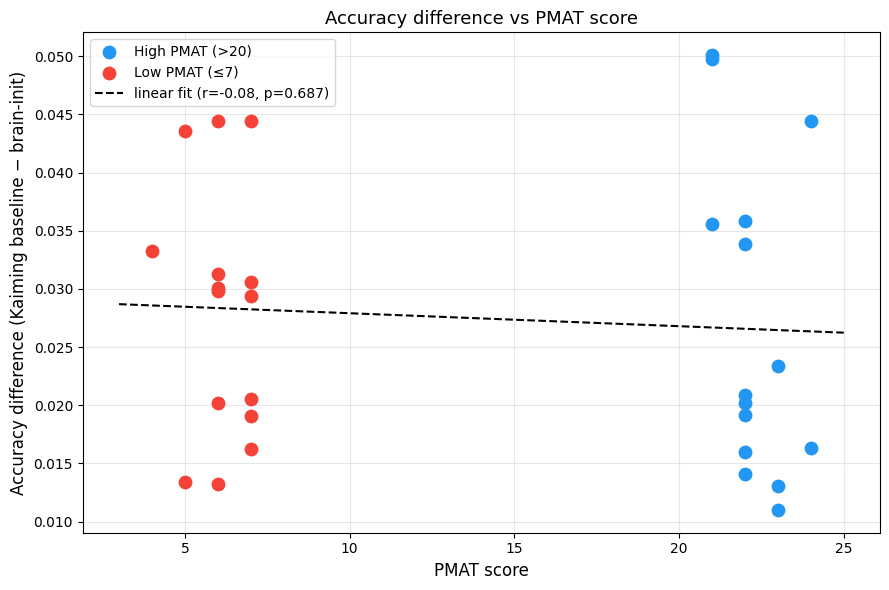

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

csv_path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/HCP_YA_subjects_2026_04_02_12_52_45.csv'
df = pd.read_csv(csv_path)

pmat_high = df[df['Subject'].isin(subject_id_list_high_pmat)].set_index('Subject')['PMAT24_A_CR']
pmat_low  = df[df['Subject'].isin(subject_id_list_low_pmat)].set_index('Subject')['PMAT24_A_CR']

pmat_values_high = np.array([pmat_high[s] for s in subject_id_list_high_pmat])
pmat_values_low  = np.array([pmat_low[s]  for s in subject_id_list_low_pmat])

all_pmat = np.concatenate([pmat_values_high, pmat_values_low])
all_diff = np.concatenate([high, low])
all_labels = ['High PMAT'] * len(high) + ['Low PMAT'] * len(low)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(pmat_values_high, high, color='#2196F3', s=80, label='High PMAT (>20)', zorder=3)
ax.scatter(pmat_values_low,  low,  color='#F44336', s=80, label='Low PMAT (≤7)',   zorder=3)

# Regression line across all subjects
slope, intercept, r, p, _ = stats.linregress(all_pmat, all_diff)
x_line = np.linspace(all_pmat.min() - 1, all_pmat.max() + 1, 200)
ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5, linestyle='--',
        label=f'linear fit (r={r:.2f}, p={p:.3f})')

ax.set_xlabel("PMAT score", fontsize=12)
ax.set_ylabel("Accuracy difference (Kaiming baseline − brain-init)", fontsize=12)
ax.set_title("Accuracy difference vs PMAT score", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1 hidden layer MLP

## All subjects

## PMAT > 20

In [ ]:
import numpy as np  
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat higher than 20 one hidden layer'
best_result_high = np.load(path + '/val_acc_194443_random_kaiming.npy')
print(f"Best accuracy with random Kaiming init (high PMAT): {best_result_high.max():.4f}")
print('\n')

subject_id_list_high_pmat = [209531, 984472, 185139, 177645, 908860, 713239, 749058, 690152, 815247,
   638049, 635245, 601127, 513736, 175338, 194443]

best_accuracies_high_pmat = []
best_accuracies_difference_high_pmat = []
for subject_id in subject_id_list_high_pmat:
    result = np.load(path + f'/val_acc_{subject_id}.npy')
    current_best = result.max()
    best_accuracies_high_pmat.append(current_best)
    best_accuracies_difference_high_pmat.append(best_result_high.max() - current_best)

print(best_accuracies_high_pmat)
print(f"Mean best accuracy (high PMAT): {np.mean(best_accuracies_high_pmat):.4f}")
print(f"Standard deviation (high PMAT): {np.std(best_accuracies_high_pmat):.4f}")
print(f"Best accuracy across all high PMAT subjects: {np.max(best_accuracies_high_pmat):.4f}")

[np.float64(0.9564), np.float64(0.9548), np.float64(0.9628), np.float64(0.9614), np.float64(0.9543), np.float64(0.9514), np.float64(0.9648), np.float64(0.9486), np.float64(0.9404), np.float64(0.9495), np.float64(0.9624), np.float64(0.9646), np.float64(0.9566), np.float64(0.9443), np.float64(0.9533), np.float64(0.9636), np.float64(0.9526), np.float64(0.9443), np.float64(0.9493), np.float64(0.9478), np.float64(0.9388), np.float64(0.9636), np.float64(0.9717), np.float64(0.9535), np.float64(0.9568), np.float64(0.9462), np.float64(0.9593), np.float64(0.9632), np.float64(0.9543), np.float64(0.9439)]
Mean best accuracy: 0.9545
Standard deviation of best accuracies: 0.0080
Mean accuracy difference: 0.0241
Standard deviation of accuracy differences: 0.0085


In [41]:
import numpy as np

path_1 = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjetcs with pmat lower than 7 one hidden layer'
path_2 = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjects with pmat higher than 20 one hidden layer'

best_result_high = np.load(path_1 + '/val_acc_208630_random_kaiming.npy')

subjects_list = [209531, 984472, 185139, 177645, 908860, 713239,
749058, 690152, 815247,
    638049, 635245, 601127, 513736, 175338, 194443, 169343, 180129,
181131, 183337, 186141, 189450, 194140, 208428, 208630,
    212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies_male = []
best_accuracies_female = []
best_accuracy_differences_male = []
best_accuracy_differences_female = []

for subject_id in subjects_list:
    try:
        result = np.load(path_1 + f'/val_acc_{subject_id}.npy')
    except:
        result = np.load(path_2 + f'/val_acc_{subject_id}.npy')

    current_best = result.max()
    sid = subject_id if subject_id in data else str(subject_id)
    gender = data[sid]['gender']

    if gender == 'M':
        best_accuracies_male.append(current_best)
        best_accuracy_differences_male.append(best_result_high -
current_best)
    else:
        best_accuracies_female.append(current_best)
        best_accuracy_differences_female.append(best_result_high -
current_best)

for label, accs, diffs in [('Male', best_accuracies_male,
best_accuracy_differences_male),
                            ('Female', best_accuracies_female,
best_accuracy_differences_female)]:
    print(f"\n=== {label} (n={len(accs)}) ===")
    print(f"  Accuracies : {accs}")
    print(f"  Mean accuracy      : {np.mean(accs):.4f}")
    print(f"  Std accuracy       : {np.std(accs):.4f}")
    print(f"  Mean diff (Kaiming - brain-init): {np.mean(diffs):.4f}")
    print(f"  Std  diff                       : {np.std(diffs):.4f}")


=== Male (n=14) ===
  Accuracies : [np.float64(0.9543), np.float64(0.9648), np.float64(0.9486), np.float64(0.9404), np.float64(0.9624), np.float64(0.9646), np.float64(0.9533), np.float64(0.9478), np.float64(0.9388), np.float64(0.9535), np.float64(0.9462), np.float64(0.9593), np.float64(0.9543), np.float64(0.9439)]
  Mean accuracy      : 0.9523
  Std accuracy       : 0.0082
  Mean diff (Kaiming - brain-init): 0.0263
  Std  diff                       : 0.0086

=== Female (n=16) ===
  Accuracies : [np.float64(0.9564), np.float64(0.9548), np.float64(0.9628), np.float64(0.9614), np.float64(0.9514), np.float64(0.9495), np.float64(0.9566), np.float64(0.9443), np.float64(0.9636), np.float64(0.9526), np.float64(0.9443), np.float64(0.9493), np.float64(0.9636), np.float64(0.9717), np.float64(0.9568), np.float64(0.9632)]
  Mean accuracy      : 0.9564
  Std accuracy       : 0.0074
  Mean diff (Kaiming - brain-init): 0.0222
  Std  diff                       : 0.0079


## PMAT <= 7

In [30]:
import numpy as np  
path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Project/subjetcs with pmat lower than 7 one hidden layer'
best_result_low = np.load(path + '/val_acc_208630_random_kaiming.npy')
print(f"Best accuracy with random Kaiming init (low PMAT): {best_result_low.max():.4f}")
print('\n')

subject_id_list_low_pmat = [169343, 180129, 181131, 183337, 186141, 189450, 194140, 208428, 208630,
   212217, 217126, 571548, 579665, 588565, 668361]

best_accuracies_low_pmat = []
best_accuracies_difference_low_pmat = []
for subject_id in subject_id_list_low_pmat:
    result = np.load(path + f'/val_acc_{subject_id}.npy')
    current_best = result.max()
    best_accuracies_low_pmat.append(current_best)
    best_accuracies_difference_low_pmat.append(best_result_low.max() - current_best)

print(best_accuracies_low_pmat)
print(f"Mean best accuracy (low PMAT): {np.mean(best_accuracies_low_pmat):.4f}")
print(f"Standard deviation (low PMAT): {np.std(best_accuracies_low_pmat):.4f}")
print(f"Best accuracy across all low PMAT subjects: {np.max(best_accuracies_low_pmat):.4f}")

Best accuracy with random Kaiming init (low PMAT): 0.9827


[np.float64(0.9636), np.float64(0.9526), np.float64(0.9443), np.float64(0.9493), np.float64(0.9478), np.float64(0.9388), np.float64(0.9636), np.float64(0.9717), np.float64(0.9535), np.float64(0.9568), np.float64(0.9462), np.float64(0.9593), np.float64(0.9632), np.float64(0.9543), np.float64(0.9439)]
Mean best accuracy (low PMAT): 0.9539
Standard deviation (low PMAT): 0.0088
Best accuracy across all low PMAT subjects: 0.9717


## Brain Network Topology vs PMAT Score

Compute graph-theoretic metrics from each subject's FC matrix (thresholded at a fixed edge density) and correlate them with fluid intelligence (PMAT24_A_CR).

In [5]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# The 30 subjects already analyzed
all_30_subjects = subject_id_list_high_pmat + subject_id_list_low_pmat

csv_path = '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/HCP_YA_subjects_2026_04_02_12_52_45.csv'
df_meta = pd.read_csv(csv_path)
df_topo = (
    df_meta[df_meta['Subject'].isin(all_30_subjects)]
    .dropna(subset=['PMAT24_A_CR'])
    .reset_index(drop=True)
)
df_topo['group'] = df_topo['Subject'].apply(
    lambda s: 'High PMAT (>20)' if s in subject_id_list_high_pmat else 'Low PMAT (≤7)'
)
print(f"Subjects: {len(df_topo)}")
print(df_topo[['Subject', 'Gender', 'Age_in_Yrs', 'PMAT24_A_CR', 'group']].to_string())

Subjects: 30
    Subject Gender  Age_in_Yrs  PMAT24_A_CR            group
0    169343      F          33          6.0    Low PMAT (≤7)
1    175338      F          22         21.0  High PMAT (>20)
2    177645      F          29         22.0  High PMAT (>20)
3    180129      F          27          7.0    Low PMAT (≤7)
4    181131      F          33          6.0    Low PMAT (≤7)
5    183337      F          35          6.0    Low PMAT (≤7)
6    185139      F          31         22.0  High PMAT (>20)
7    186141      M          31          6.0    Low PMAT (≤7)
8    189450      M          23          6.0    Low PMAT (≤7)
9    194140      F          30          5.0    Low PMAT (≤7)
10   194443      M          27         22.0  High PMAT (>20)
11   208428      F          32          5.0    Low PMAT (≤7)
12   208630      M          33          7.0    Low PMAT (≤7)
13   209531      F          36         21.0  High PMAT (>20)
14   212217      F          23          7.0    Low PMAT (≤7)
15   217126

In [11]:
DENSITY = 0.20  # keep top 20 % of positive edges (proportional thresholding)

def build_graph(fc, density=DENSITY):
    n = fc.shape[0]
    tri = np.triu(fc, k=1).copy()
    tri[tri < 0] = 0.0
    vals = tri[tri > 0]
    if len(vals) == 0:
        return nx.empty_graph(n)
    cutoff = np.percentile(vals, (1 - density) * 100)
    adj = ((tri >= cutoff) * 1.0)
    adj = adj + adj.T
    return nx.from_numpy_array(adj)


def graph_metrics(G):
    degrees = np.array([d for _, d in G.degree()])
    bc      = nx.betweenness_centrality(G, normalized=True)  # exact — only 30 subjects
    rc_dict = nx.rich_club_coefficient(G, normalized=False)
    k75     = int(np.percentile(degrees, 75))
    return dict(
        mean_degree=degrees.mean(),
        clustering=nx.average_clustering(G),
        global_efficiency=nx.global_efficiency(G),
        mean_betweenness=np.mean(list(bc.values())),
        rich_club_k75=rc_dict.get(k75, np.nan),
    )


records = []
for _, row in df_topo.iterrows():
    sid = str(int(row['Subject']))
    fc  = data[sid]['FC']
    G   = build_graph(fc)
    m   = graph_metrics(G)
    m['subject'] = int(row['Subject'])
    m['pmat']    = row['PMAT24_A_CR']
    m['gender']  = row['Gender']
    m['age']     = row['Age_in_Yrs']
    m['group']   = row['group']
    records.append(m)

df_gm = pd.DataFrame(records)
print(f"Metrics computed for {len(df_gm)} subjects")
df_gm[['subject', 'group', 'pmat', 'mean_degree', 'clustering', 'global_efficiency', 'mean_betweenness', 'rich_club_k75']]

Metrics computed for 30 subjects


,subject,group,pmat,mean_degree,clustering,global_efficiency,mean_betweenness,rich_club_k75
0,169343,Low PMAT (≤7),6.0,69.044855,0.590456,0.546503,0.002681,0.476372
1,175338,High PMAT (>20),21.0,73.630607,0.579220,0.566194,0.002657,0.685144
2,177645,High PMAT (>20),22.0,65.261214,0.606691,0.520970,0.003110,0.710638
3,180129,Low PMAT (≤7),7.0,74.258575,0.607801,0.552303,0.002612,0.777828
4,181131,Low PMAT (≤7),6.0,72.216359,0.605347,0.473069,0.003104,0.974916
5,183337,Low PMAT (≤7),6.0,72.928760,0.590747,0.532220,0.002941,0.876660
6,185139,High PMAT (>20),22.0,70.332454,0.555698,0.550916,0.002680,0.794177
7,186141,Low PMAT (≤7),6.0,73.377309,0.603013,0.539605,0.002691,0.835386
8,189450,Low PMAT (≤7),6.0,72.722955,0.637001,0.517433,0.003100,0.919469
9,194140,Low PMAT (≤7),5.0,67.941953,0.614831,0.504968,0.003254,0.868309


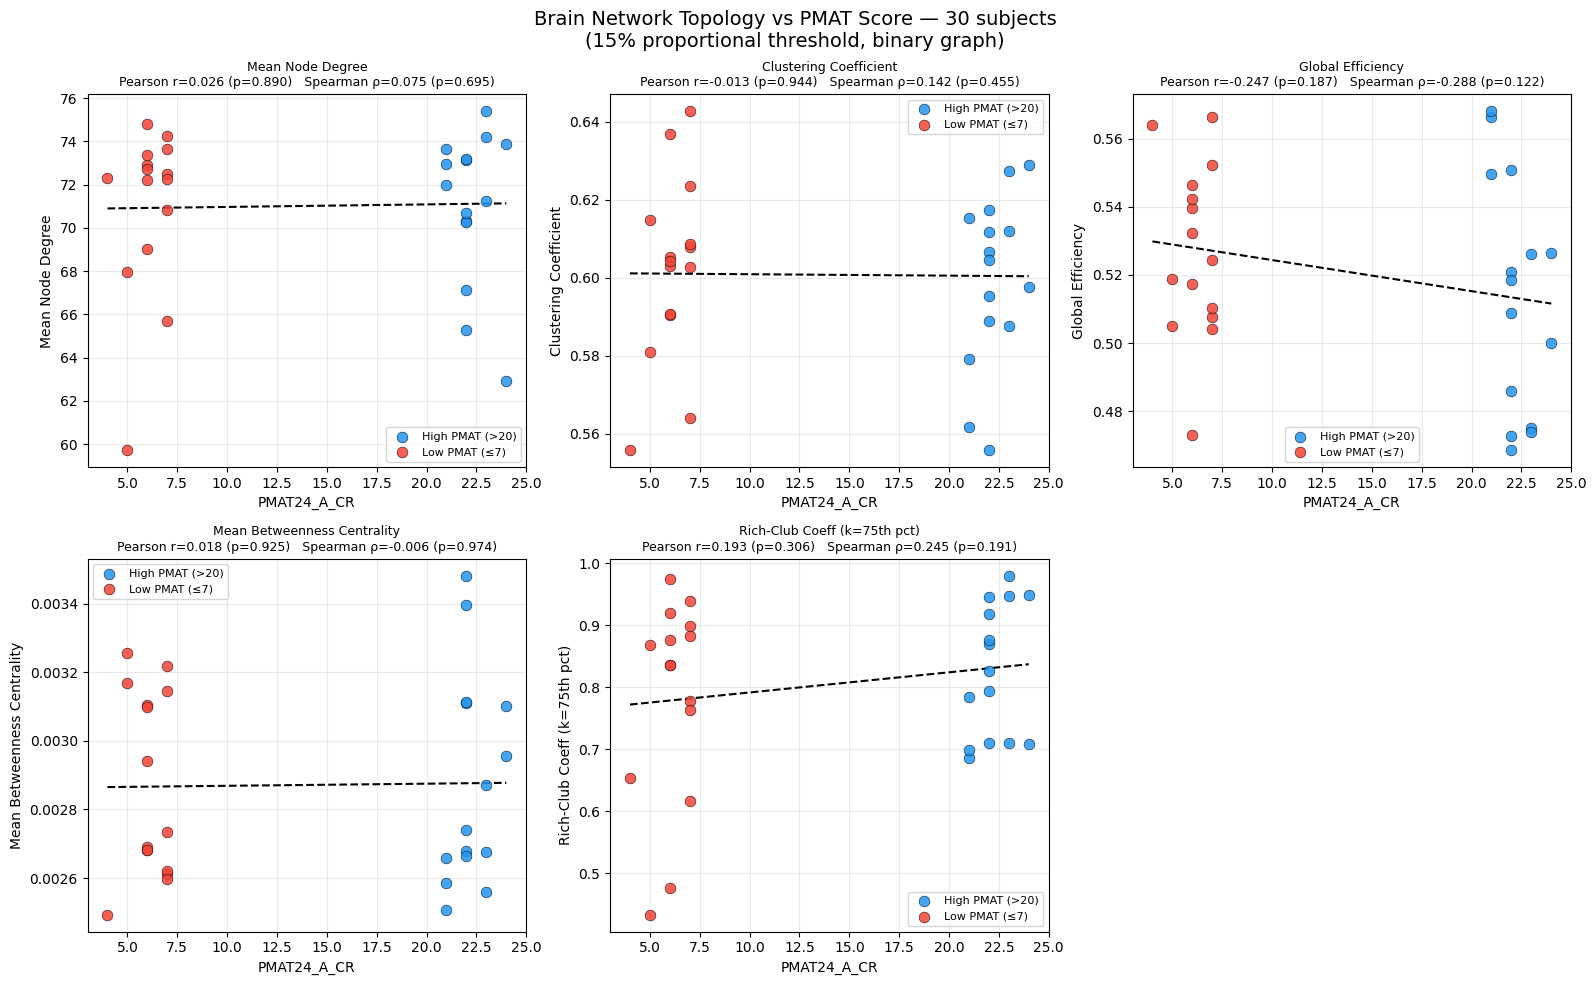

In [12]:
metric_cols = ['mean_degree', 'clustering', 'global_efficiency', 'mean_betweenness', 'rich_club_k75']
metric_labels = {
    'mean_degree':        'Mean Node Degree',
    'clustering':         'Clustering Coefficient',
    'global_efficiency':  'Global Efficiency',
    'mean_betweenness':   'Mean Betweenness Centrality',
    'rich_club_k75':      'Rich-Club Coeff (k=75th pct)',
}
group_colors = {'High PMAT (>20)': '#2196F3', 'Low PMAT (≤7)': '#F44336'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Brain Network Topology vs PMAT Score — 30 subjects\n(15% proportional threshold, binary graph)', fontsize=14)
axes = axes.flatten()

for ax, col in zip(axes, metric_cols):
    sub = df_gm[['pmat', col, 'group']].dropna()
    x, y = sub['pmat'].values, sub[col].values

    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)

    for grp, grp_df in sub.groupby('group'):
        ax.scatter(grp_df['pmat'], grp_df[col],
                   color=group_colors[grp], s=60, alpha=0.85,
                   edgecolors='black', linewidths=0.4, label=grp, zorder=3)

    slope, intercept = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr, slope * xr + intercept, color='black', linewidth=1.5, linestyle='--')

    ax.set_xlabel('PMAT24_A_CR', fontsize=10)
    ax.set_ylabel(metric_labels[col], fontsize=10)
    ax.set_title(
        f'{metric_labels[col]}\n'
        f'Pearson r={r_p:.3f} (p={p_p:.3f})   Spearman ρ={r_s:.3f} (p={p_s:.3f})',
        fontsize=9,
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

=== High PMAT vs Low PMAT — group comparison ===

                                     High_mean          Low_mean SW_normal  t_stat   p_ttest U_stat     p_MWU Cohens_d Rank_biserial_r
Metric                                                                                                                                
Mean Node Degree              71.0867 ± 3.3950  70.9506 ± 3.8289        no   0.100  0.921 ns  112.0  1.000 ns    0.036           0.004
Clustering Coefficient         0.5993 ± 0.0210   0.6021 ± 0.0229       yes  -0.334  0.741 ns  108.0  0.868 ns   -0.122           0.040
Global Efficiency              0.5141 ± 0.0332   0.5269 ± 0.0246       yes  -1.160  0.256 ns   91.0  0.384 ns   -0.424           0.191
Mean Betweenness Centrality    0.0029 ± 0.0003   0.0029 ± 0.0003        no   0.037  0.971 ns  106.0  0.803 ns    0.013           0.058
Rich-Club Coeff (k=75th pct)   0.8269 ± 0.1034   0.7835 ± 0.1605        no   0.851  0.402 ns  125.0  0.619 ns    0.311          -0.111


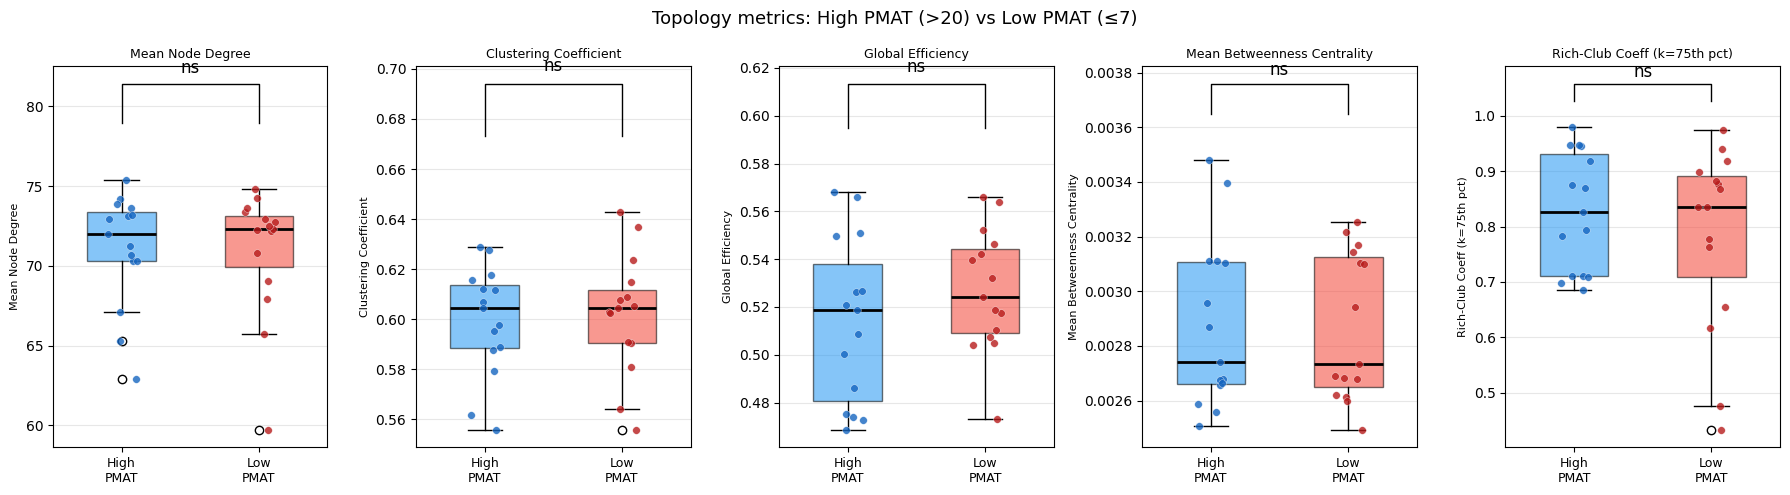

In [13]:
from scipy import stats as sp_stats
import warnings

high_df = df_gm[df_gm['group'] == 'High PMAT (>20)']
low_df  = df_gm[df_gm['group'] == 'Low PMAT (≤7)']

def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else np.nan

def rank_biserial(u_stat, n1, n2):
    """Effect size for Mann-Whitney U."""
    return 1 - (2 * u_stat) / (n1 * n2)

def significance_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

rows = []
for col in metric_cols:
    h = high_df[col].dropna().values
    l = low_df[col].dropna().values

    # Shapiro-Wilk normality
    _, p_sw_h = sp_stats.shapiro(h)
    _, p_sw_l = sp_stats.shapiro(l)
    normal = p_sw_h > 0.05 and p_sw_l > 0.05

    # Independent t-test
    t_stat, p_t = sp_stats.ttest_ind(h, l)

    # Mann-Whitney U (non-parametric)
    u_stat, p_mwu = sp_stats.mannwhitneyu(h, l, alternative='two-sided')

    # Effect sizes
    d   = cohens_d(h, l)
    rbc = rank_biserial(u_stat, len(h), len(l))

    rows.append(dict(
        Metric          = metric_labels[col],
        High_mean       = f'{h.mean():.4f} ± {h.std():.4f}',
        Low_mean        = f'{l.mean():.4f} ± {l.std():.4f}',
        SW_normal       = 'yes' if normal else 'no',
        t_stat          = f'{t_stat:.3f}',
        p_ttest         = f'{p_t:.3f} {significance_stars(p_t)}',
        U_stat          = f'{u_stat:.1f}',
        p_MWU           = f'{p_mwu:.3f} {significance_stars(p_mwu)}',
        Cohens_d        = f'{d:.3f}',
        Rank_biserial_r = f'{rbc:.3f}',
    ))

df_tests = pd.DataFrame(rows).set_index('Metric')
print("=== High PMAT vs Low PMAT — group comparison ===\n")
print(df_tests.to_string())

# --- Grouped bar chart with individual data points ---
fig, axes = plt.subplots(1, len(metric_cols), figsize=(18, 5))
fig.suptitle('Topology metrics: High PMAT (>20) vs Low PMAT (≤7)', fontsize=13)

for ax, col in zip(axes, metric_cols):
    h_vals = high_df[col].dropna().values
    l_vals = low_df[col].dropna().values

    _, p_mwu = sp_stats.mannwhitneyu(h_vals, l_vals, alternative='two-sided')

    positions = [0, 1]
    bp = ax.boxplot([h_vals, l_vals], positions=positions, widths=0.5,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#2196F3', '#F44336']):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    # Jittered individual points
    for vals, pos, color in [(h_vals, 0, '#1565C0'), (l_vals, 1, '#B71C1C')]:
        jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(vals))
        ax.scatter(pos + jitter, vals, color=color, s=30, alpha=0.8, zorder=3, edgecolors='white', linewidths=0.3)

    # Significance bracket
    y_max = max(np.max(h_vals), np.max(l_vals))
    y_top = y_max * 1.08
    ax.plot([0, 0, 1, 1], [y_top * 0.97, y_top, y_top, y_top * 0.97], color='black', linewidth=1)
    ax.text(0.5, y_top * 1.005, significance_stars(p_mwu), ha='center', va='bottom', fontsize=12)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['High\nPMAT', 'Low\nPMAT'], fontsize=9)
    ax.set_title(metric_labels[col], fontsize=9)
    ax.set_ylabel(metric_labels[col], fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

=== Topology–PMAT Correlation Summary ===
                             Pearson_r Pearson_p Spearman_rho Spearman_p   N
Metric                                                                      
Mean Node Degree                 0.026  0.890 ns        0.075   0.695 ns  30
Clustering Coefficient          -0.013  0.944 ns        0.142   0.455 ns  30
Global Efficiency               -0.247  0.187 ns       -0.288   0.122 ns  30
Mean Betweenness Centrality      0.018  0.925 ns       -0.006   0.974 ns  30
Rich-Club Coeff (k=75th pct)     0.193  0.306 ns        0.245   0.191 ns  30


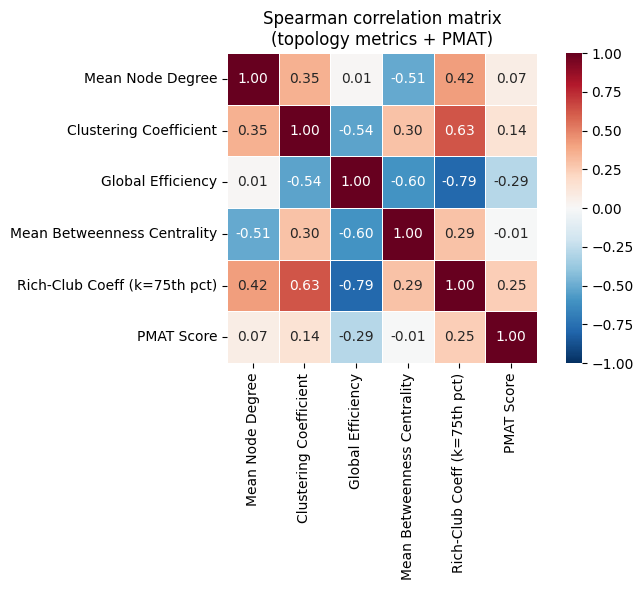

In [14]:
# Summary correlation table + significance stars
rows = []
for col in metric_cols:
    sub = df_gm[['pmat', col]].dropna()
    x, y = sub['pmat'].values, sub[col].values
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)

    def stars(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return 'ns'

    rows.append(dict(
        Metric=metric_labels[col],
        Pearson_r=f'{r_p:.3f}',
        Pearson_p=f'{p_p:.3f} {stars(p_p)}',
        Spearman_rho=f'{r_s:.3f}',
        Spearman_p=f'{p_s:.3f} {stars(p_s)}',
        N=len(sub),
    ))

df_corr_summary = pd.DataFrame(rows).set_index('Metric')
print("=== Topology–PMAT Correlation Summary ===")
print(df_corr_summary.to_string())

# Heatmap of the raw correlations alongside topology metrics and PMAT
heatmap_cols = metric_cols + ['pmat']
heatmap_labels = [metric_labels[c] for c in metric_cols] + ['PMAT Score']
corr_mat = df_gm[heatmap_cols].dropna().rename(columns={**metric_labels, 'pmat': 'PMAT Score'}).corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, square=True, ax=ax,
    linewidths=0.5, linecolor='white',
)
ax.set_title('Spearman correlation matrix\n(topology metrics + PMAT)', fontsize=12)
plt.tight_layout()
plt.show()